# Plot Figure S12 - Gradients

This notebook generates the main data figure comparing fluorescent gradients in HQNO and RHL reporters for different PA strains (WT and those deficient in HQNO and or RHL production).

Code for the additional figure panels, containing model fitting, are provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel)  

In [10]:
# Data analysis packages
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization packages
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [11]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Matplotlib style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 8
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


# Strain colors
COLORS_H = {
    'wt': '#ffcc66',       
    '∆pqsL': '#669966',    
    '∆pqsL ∆rhlA': '#9999B3' 
}

COLORS_R = {
    'wt': '#ffcc66',       
    '∆rhlA': '#cc99ff',    
    '∆rhlA ∆pqsL': '#9999B3' 
}


# =============================================================================
# LOAD DATA
# =============================================================================

# Load regrowth fraction data from all strains (relative paths)
df_hqno = pd.read_csv('../analysis_code/0_combined_df_hqno.csv')
df_rhl = pd.read_csv('../analysis_code/0_combined_df_rhl.csv')


# =============================================================================
# BIN DATA
# =============================================================================

def bin_data(df, color_channel = 'gfp', correction_quantile=0.0):
    """
    Bin and process fluorescence data.

    Parameters
    ----------
    df : pd.DataFrame
    correction_quantile : float, optional
        Quantile (0–1) of median_intensity used as the per-chamber baseline
        that is subtracted to produce corrected_intensity.
        0.0 (default) uses the minimum value.
    """

    # --- Convert to micrometers ---
    pixel_to_um = 0.065
    df['x_um'] = df['x'] * pixel_to_um
    df['y_um'] = df['y'] * pixel_to_um

    # --- Define manual bins (1.5um fixed size) ---
    manual_y_bins = np.linspace(0, 54, 37)
    num_y_bins = len(manual_y_bins) - 1

    # --- Assign bins ---
    df['y_bin'] = np.digitize(df['y_um'], manual_y_bins, right=False) - 1

    # Clip to valid range
    df['y_bin'] = df['y_bin'].clip(0, num_y_bins - 1)

    # Calculate bin centers and add to dataframe
    y_bin_centers = (manual_y_bins[:-1] + manual_y_bins[1:]) / 2
    df['y_um_center'] = y_bin_centers[df['y_bin']]

    # --- Calculate median intensity per replicate, position, and y_bin ---
    df_data = (df.groupby(['strain', 'replicate', 'pos', 'y_bin'])[[f'intensity_raw_{color_channel}'] ]
            .median()
            .reset_index()
            .rename(columns={f'intensity_raw_{color_channel}': f'median intensity {color_channel}'}))

    # Add y_um centers
    df_data['y_um'] = y_bin_centers[df_data['y_bin']]

    # add unique chamber ID
    df_data['chamber_id'] = df_data['replicate'].astype(str) + '_' + df_data['pos'].astype(str)

    # --- Subtract per-chamber baseline (xth quantile of median_intensity) ---
    baseline = (df_data
                .groupby(['strain', 'chamber_id'])['median intensity ' + color_channel]
                .quantile(correction_quantile)
                .rename('baseline'))
    df_data = df_data.join(baseline, on=['strain', 'chamber_id'])
    df_data['corrected intensity ' + color_channel] = df_data['median intensity ' + color_channel] - df_data['baseline']
    df_data = df_data.drop(columns='baseline')

    return df_data

df_data_hqno = bin_data(df_hqno, color_channel='gfp', correction_quantile=0.01)
df_data_rhl = bin_data(df_rhl, color_channel='mcherry', correction_quantile=0.01)

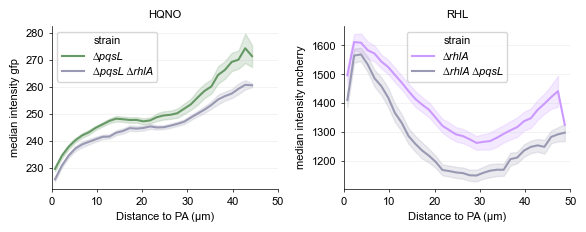

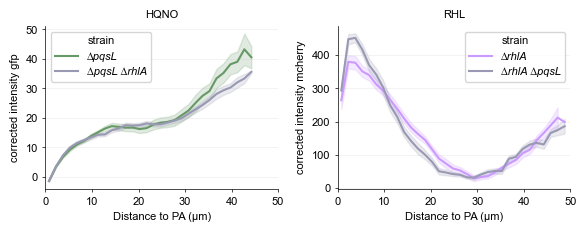

In [16]:
# --- Generate figure ---
final_width_in = 2.5*6 / 2.54
final_height_in = 6 / 2.54

# --- Plot raw median intensities ---
OUTPUT_FIGURE = 'S12_gradients.pdf'

fig, axs = plt.subplots(1,2,figsize=(final_width_in, final_height_in))
sns.lineplot(
    data=df_data_hqno,
    x='y_um',
    y='median intensity gfp',
    hue='strain',
    palette=COLORS_H,
    errorbar ='se',
    ax=axs[0],
)

sns.lineplot(
    data=df_data_rhl,
    x='y_um',
    y='median intensity mcherry',
    hue='strain',
    palette=COLORS_R,
    errorbar ='se',
    ax=axs[1]
)

# Subplot titles
axs[0].set_title('HQNO', fontsize=8)
axs[1].set_title('RHL', fontsize=8)

# Axes labels and limits
for ax in axs:
    ax.set_xlabel('Distance to PA (µm)', fontsize=8)
    ax.set_xlim(0, 50)
    ax.set_xticks([0, 10, 20, 30, 40, 50])

    # Style (minimal spines, subtle grid)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
    ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

    # Italic legend entries, non-italic title
    legend = ax.get_legend()
    if legend is not None:
        legend.get_title().set_fontstyle('normal')
        for text in legend.get_texts():
            text.set_fontstyle('italic')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)

# --- Plot corrected intensities ---
OUTPUT_FIGURE = 'S12_gradients_corrected.pdf'
fig, axs = plt.subplots(1,2,figsize=(final_width_in, final_height_in))

sns.lineplot(
    data=df_data_hqno,
    x='y_um',
    y='corrected intensity gfp',
    hue='strain',
    palette=COLORS_H,
    errorbar ='se',
    ax=axs[0]
)

sns.lineplot(
    data=df_data_rhl,
    x='y_um',
    y='corrected intensity mcherry',
    hue='strain',
    palette=COLORS_R,
    errorbar ='se',
    ax=axs[1]
)

# Subplot titles
axs[0].set_title('HQNO', fontsize=8)
axs[1].set_title('RHL', fontsize=8)

# Axes labels and limits
for ax in axs:
    ax.set_xlabel('Distance to PA (µm)', fontsize=8)
    ax.set_xlim(0, 50)
    ax.set_xticks([0, 10, 20, 30, 40, 50])

    # Style (minimal spines, subtle grid)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(axis='both', which='major', width=0.5, length=2, labelsize=8)
    ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

    # Italic legend entries, non-italic title
    legend = ax.get_legend()
    if legend is not None:
        legend.get_title().set_fontstyle('normal')
        for text in legend.get_texts():
            text.set_fontstyle('italic')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, format='pdf', bbox_inches='tight', dpi=300)
